# Compare-Map Visualisations

This notebook loads a `metrics.jsonl` generated by `nas/compare-track.py`,
builds a table where rows are architectures and columns are maps, and then
plots the RMSEs so different planners can be compared at a glance.

Adjust the `RUN_DIR` value in the next cell if you want to point at a specific
run directory under `nas/compare-map/`. By default it selects the newest one.


In [25]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

try:
    BASE_OUTPUT_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_OUTPUT_DIR = Path.cwd()


def latest_run_dir(base_dir: Path = BASE_OUTPUT_DIR) -> Path:
    candidates = sorted(
        [path for path in base_dir.glob("*/metrics.jsonl")],
        key=lambda p: p.stat().st_mtime,
    )
    if not candidates:
        raise FileNotFoundError(
            f"No metrics.jsonl files found under {base_dir}. Run nas/compare-track.py first."
        )
    return candidates[-1].parent

RUN_DIR_OVERRIDE: Path | str | None = "381bf7"  # e.g., "compare_20260410T133741"
# RUN_DIR_OVERRIDE: Path | str | None = None


def resolve_run_dir() -> Path:
    if RUN_DIR_OVERRIDE:
        candidate = Path(RUN_DIR_OVERRIDE)
        if not candidate.is_absolute():
            candidate = BASE_OUTPUT_DIR / candidate
        if candidate.is_file():
            candidate = candidate.parent
        if not candidate.exists():
            raise FileNotFoundError(
                f"Override directory {candidate} was not found. Update RUN_DIR_OVERRIDE."
            )
        metrics_file = candidate / "metrics.jsonl"
        if not metrics_file.exists():
            raise FileNotFoundError(
                f"{metrics_file} was not found; choose a directory containing metrics.jsonl."
            )
        return candidate
    return latest_run_dir()

RUN_DIR = resolve_run_dir()
METRICS_FILE = RUN_DIR / "metrics.jsonl"
print(f"Using metrics from: {RUN_DIR}")

with METRICS_FILE.open("r", encoding="utf-8") as fh:
    METRIC_RECORDS = [json.loads(line) for line in fh if line.strip()]

if not METRIC_RECORDS:
    raise RuntimeError(f"{METRICS_FILE} is empty; rerun compare-track.")

rows: list[dict[str, object]] = []
for record in METRIC_RECORDS:
    map_name = record["map"]
    for run in record["runs"]:
        rows.append(
            {
                "map": map_name,
                "arch": run["label"],
                "rmse": run.get("rmse"),
            }
        )

df = pd.DataFrame(rows)
pivot = df.pivot_table(index="arch", columns="map", values="rmse")
pivot = pivot.sort_index()
print(f"Loaded RMSE table with shape {pivot.shape} (arches x maps).")


Using metrics from: /Users/zayahcortright/DAX.nosync/f1tenth_ng_zc/nas/compare-map/381bf7
Loaded RMSE table with shape (8, 8) (arches x maps).


## RMSE table

Rows correspond to planner architectures; columns are maps. Each cell contains the
cross-track RMSE (in metres) reported by the simulator.


In [26]:
display(
    pivot.style
    .format("{:.4f}")
    .background_gradient(axis=0, cmap="YlGnBu")
    .set_properties(**{"text-align": "center"})
)


map,F1/Budapest/Budapest,F1/MexicoCity/MexicoCity,F1/Monza/Monza,F1/Nuerburgring/Nuerburgring,F1/Shanghai/Shanghai,F1/Silverstone/Silverstone,F1/Sochi/Sochi,F1/Spa/Spa
arch,,,,,,,,
arch1,0.1157,0.1337,0.0934,0.0938,0.1375,0.0927,0.1027,0.0910
arch2,0.1149,0.1243,0.0930,0.1000,0.1376,0.0946,0.0869,0.0913
arch3,0.1049,0.1480,0.0887,0.1082,0.1658,0.0933,0.1231,0.0816
arch4,0.1604,0.1477,0.0929,0.1444,0.1668,0.1225,0.1242,0.1083
arch5,0.1418,0.1396,0.0970,0.1404,0.1599,0.1294,0.1231,0.1183
arch6,0.1394,0.1355,0.0976,0.1386,0.1492,0.1318,0.1245,0.1180
arch7,0.1464,0.1412,0.0984,0.1422,0.1727,0.1282,0.1210,0.1152
arch8,0.1413,0.1224,0.0960,0.1348,0.1640,0.1211,0.1140,0.1135


## Connected RMSE comparison

A connected scatter plot (line plot with markers) makes it easy to see trends
per architecture: each line tracks an arch across maps, so you can spot where
one suddenly performs better or worse relative to the others. The x-axis
reflects each map explicitly so every point sits exactly on its label.


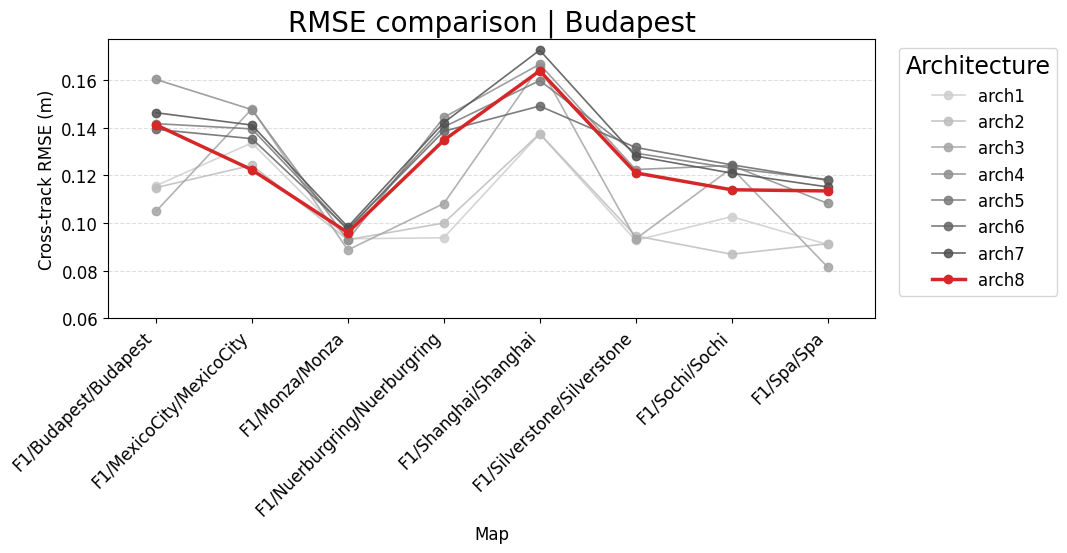

In [27]:
maps = list(pivot.columns)
x_positions = range(len(maps))
highlight_arch = "arch8"
has_highlight = highlight_arch in pivot.index
fig, ax = plt.subplots(figsize=(14, 9))
other_arches = [arch for arch in pivot.index if not (has_highlight and arch == highlight_arch)]
if other_arches:
    muted_scale = np.linspace(0.3, 0.75, len(other_arches))
    for scale, arch in zip(muted_scale, other_arches):
        color = plt.cm.Greys(scale)
        ax.plot(
            x_positions,
            pivot.loc[arch].values,
            marker="o",
            linewidth=1.2,
            color=color,
            alpha=0.85,
            label=arch,
        )
if has_highlight:
    ax.plot(
        x_positions,
        pivot.loc[highlight_arch].values,
        marker="o",
        linewidth=2.5,
        color="#d62728",
        label=highlight_arch,
    )
ax.set_xticks(list(x_positions))
ax.set_xticklabels(maps, rotation=45, ha="right")
ax.set_xlim(-0.5, len(maps) - 0.5)
ax.set_ylabel("Cross-track RMSE (m)")
ax.set_xlabel("Map")
# ax.set_title(f"RMSE comparison across maps ({RUN_DIR.name})")
ax.set_title(f"RMSE comparison | Budapest")
ax.set_ylim(bottom=0.06)
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Architecture", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.rcParams.update({
    "font.size": 122,
    "axes.titlesize": 20,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.title_fontsize": 17,
})
plt.tight_layout()
plt.show()


## Other continuous metric tables

These are the continuous metrics from `metrics.jsonl` that make sense to compare map-by-map. Status fields like `collision` and `laps_completed` are omitted.


In [28]:
metric_specs = {
    "crosstrack_std_m": {
        "title": "Cross-track standard deviation",
        "ylabel": "Cross-track std (m)",
        "table_title": "Cross-track std (m)",
        "ylim_bottom": 0.0,
    },
    "crosstrack_max_m": {
        "title": "Maximum cross-track error",
        "ylabel": "Max cross-track error (m)",
        "table_title": "Max cross-track error (m)",
        "ylim_bottom": 0.0,
    },
    "heading_error_rmse_deg": {
        "title": "Heading RMSE",
        "ylabel": "Heading RMSE (deg)",
        "table_title": "Heading RMSE (deg)",
        "ylim_bottom": 0.0,
    },
}

metric_rows: list[dict[str, object]] = []
for record in METRIC_RECORDS:
    map_name = record["map"]
    for run in record["runs"]:
        row = {"map": map_name, "arch": run["label"]}
        for metric_key in metric_specs:
            row[metric_key] = run.get(metric_key)
        metric_rows.append(row)

metric_df = pd.DataFrame(metric_rows)
metric_pivots = {
    metric_key: (
        metric_df
        .pivot_table(index="arch", columns="map", values=metric_key)
        .reindex(index=pivot.index, columns=pivot.columns)
    )
    for metric_key in metric_specs
    if metric_key in metric_df.columns and metric_df[metric_key].notna().any()
}

for metric_key, metric_pivot in metric_pivots.items():
    print(metric_specs[metric_key]["table_title"])
    display(
        metric_pivot.style
        .format("{:.4f}")
        .background_gradient(axis=0, cmap="YlGnBu")
        .set_properties(**{"text-align": "center"})
    )


Cross-track std (m)


map,F1/Budapest/Budapest,F1/MexicoCity/MexicoCity,F1/Monza/Monza,F1/Nuerburgring/Nuerburgring,F1/Shanghai/Shanghai,F1/Silverstone/Silverstone,F1/Sochi/Sochi,F1/Spa/Spa
arch,,,,,,,,
arch1,0.0728,0.0986,0.0790,0.0621,0.0952,0.0574,0.0771,0.0728
arch2,0.0736,0.0873,0.0732,0.0662,0.0939,0.0646,0.0600,0.0669
arch3,0.0847,0.1245,0.0765,0.0878,0.1449,0.0762,0.1021,0.0694
arch4,0.1180,0.1157,0.0727,0.1098,0.1252,0.0910,0.0972,0.0842
arch5,0.1044,0.1078,0.0710,0.1061,0.1237,0.0946,0.0952,0.0907
arch6,0.1013,0.1033,0.0707,0.1040,0.1140,0.0956,0.0952,0.0896
arch7,0.1064,0.1096,0.0729,0.1069,0.1335,0.0941,0.0935,0.0885
arch8,0.0995,0.0917,0.0764,0.0970,0.1204,0.0806,0.0846,0.0852


Max cross-track error (m)


map,F1/Budapest/Budapest,F1/MexicoCity/MexicoCity,F1/Monza/Monza,F1/Nuerburgring/Nuerburgring,F1/Shanghai/Shanghai,F1/Silverstone/Silverstone,F1/Sochi/Sochi,F1/Spa/Spa
arch,,,,,,,,
arch1,0.5650,0.4938,0.7185,0.3442,1.0979,0.3441,0.4518,0.5963
arch2,0.5091,0.4741,0.6814,0.4908,1.0664,0.3604,0.3735,0.5225
arch3,0.5156,0.5819,0.6761,0.4648,1.0268,0.6197,0.5200,0.6021
arch4,0.4766,0.4547,0.3806,0.4290,1.0071,0.4814,0.4035,0.4473
arch5,0.3723,0.4058,0.3570,0.4347,0.9663,0.4506,0.3661,0.3927
arch6,0.4113,0.4290,0.3512,0.4523,0.9570,0.4562,0.3755,0.4312
arch7,0.4162,0.4192,0.3781,0.4317,0.9658,0.5032,0.3748,0.4362
arch8,0.3641,0.4256,0.3848,0.3493,1.0282,0.3096,0.3808,0.4248


Heading RMSE (deg)


map,F1/Budapest/Budapest,F1/MexicoCity/MexicoCity,F1/Monza/Monza,F1/Nuerburgring/Nuerburgring,F1/Shanghai/Shanghai,F1/Silverstone/Silverstone,F1/Sochi/Sochi,F1/Spa/Spa
arch,,,,,,,,
arch1,3.9719,7.1654,5.1528,3.4150,7.2995,3.3756,4.8925,3.9991
arch2,4.2494,6.9507,5.2205,3.7226,9.5979,3.5005,4.8515,4.1449
arch3,3.9116,7.7363,5.4258,3.7129,10.4183,4.0451,5.8948,3.7341
arch4,3.5406,6.3591,4.0912,3.2395,7.5308,3.1868,4.6795,3.3894
arch5,3.1609,5.0246,3.8689,2.9039,8.6079,2.8658,4.1111,3.1697
arch6,3.1163,4.6167,3.7897,2.8522,7.8847,2.9040,3.9977,3.1150
arch7,3.2755,5.5165,4.1978,2.9476,8.4847,3.1764,4.2563,3.1969
arch8,3.5108,5.5243,4.1800,3.0779,9.1041,2.8043,4.0646,3.4545


## Connected metric comparisons

Each plot below matches the RMSE comparison style: maps on the x-axis, one line per architecture, and arch8 highlighted in red.


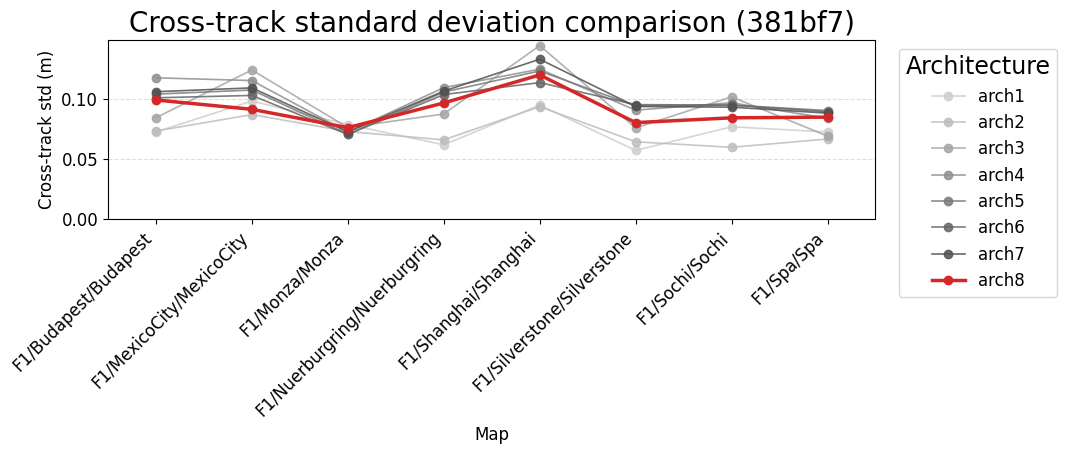

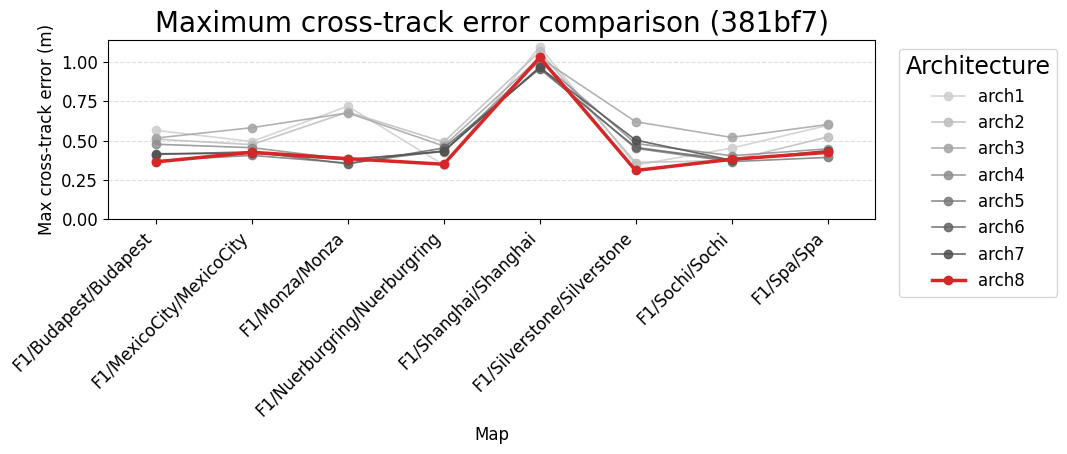

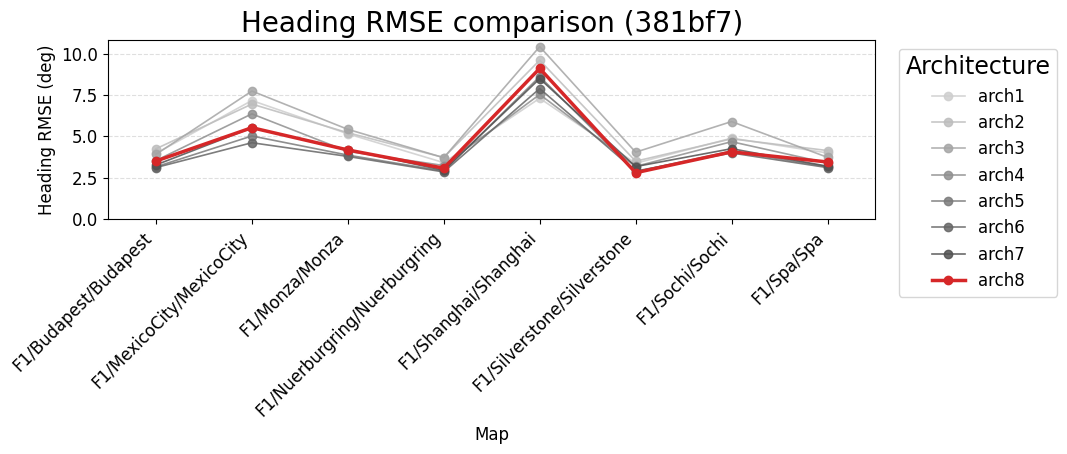

In [29]:
def plot_connected_metric(metric_pivot: pd.DataFrame, metric_key: str) -> None:
    spec = metric_specs[metric_key]
    maps = list(metric_pivot.columns)
    x_positions = range(len(maps))
    highlight_arch = "arch8"
    has_highlight = highlight_arch in metric_pivot.index

    fig, ax = plt.subplots(figsize=(14, 8))
    other_arches = [
        arch for arch in metric_pivot.index
        if not (has_highlight and arch == highlight_arch)
    ]
    if other_arches:
        muted_scale = np.linspace(0.3, 0.75, len(other_arches))
        for scale, arch in zip(muted_scale, other_arches):
            ax.plot(
                x_positions,
                metric_pivot.loc[arch].values,
                marker="o",
                linewidth=1.2,
                color=plt.cm.Greys(scale),
                alpha=0.85,
                label=arch,
            )
    if has_highlight:
        ax.plot(
            x_positions,
            metric_pivot.loc[highlight_arch].values,
            marker="o",
            linewidth=2.5,
            color="#d62728",
            label=highlight_arch,
        )

    ax.set_xticks(list(x_positions))
    ax.set_xticklabels(maps, rotation=45, ha="right")
    ax.set_xlim(-0.5, len(maps) - 0.5)
    ax.set_ylabel(spec["ylabel"])
    ax.set_xlabel("Map")
    ax.set_title(f"{spec['title']} comparison ({RUN_DIR.name})")
    ax.set_ylim(bottom=spec.get("ylim_bottom", 0.0))
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    ax.legend(title="Architecture", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

for metric_key, metric_pivot in metric_pivots.items():
    plot_connected_metric(metric_pivot, metric_key)
